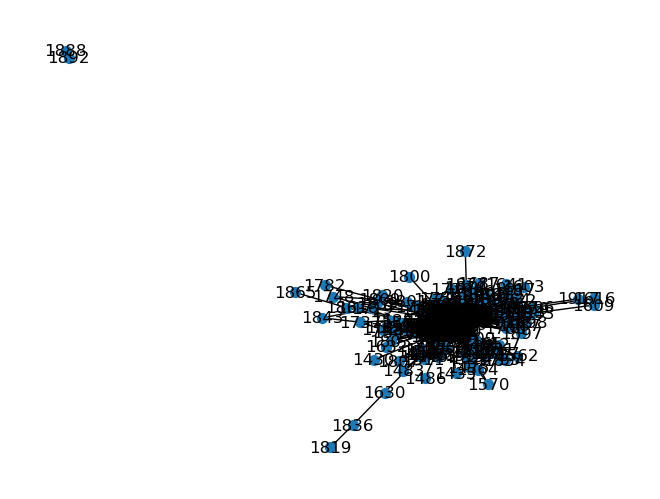

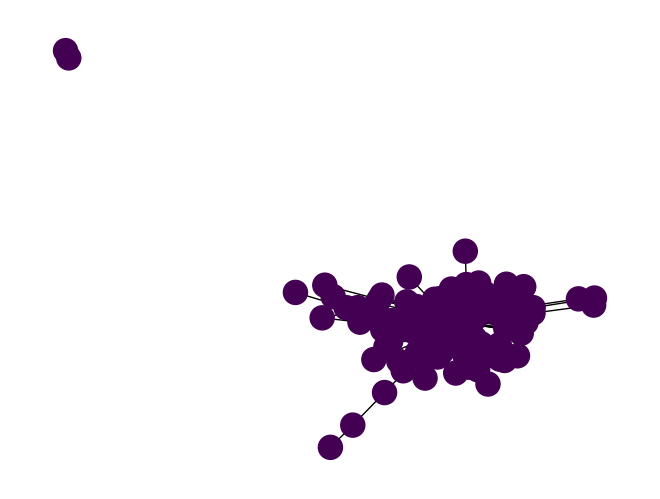

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.read_gml("primaryschool/primaryschool_s_1.gml")

# 简单绘制
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=50)
plt.show()

# 带属性的绘制
node_colors = [G.nodes[n].get('value', 0.5) for n in G.nodes]
nx.draw(G, pos, node_color=node_colors, cmap=plt.cm.viridis)
plt.show()

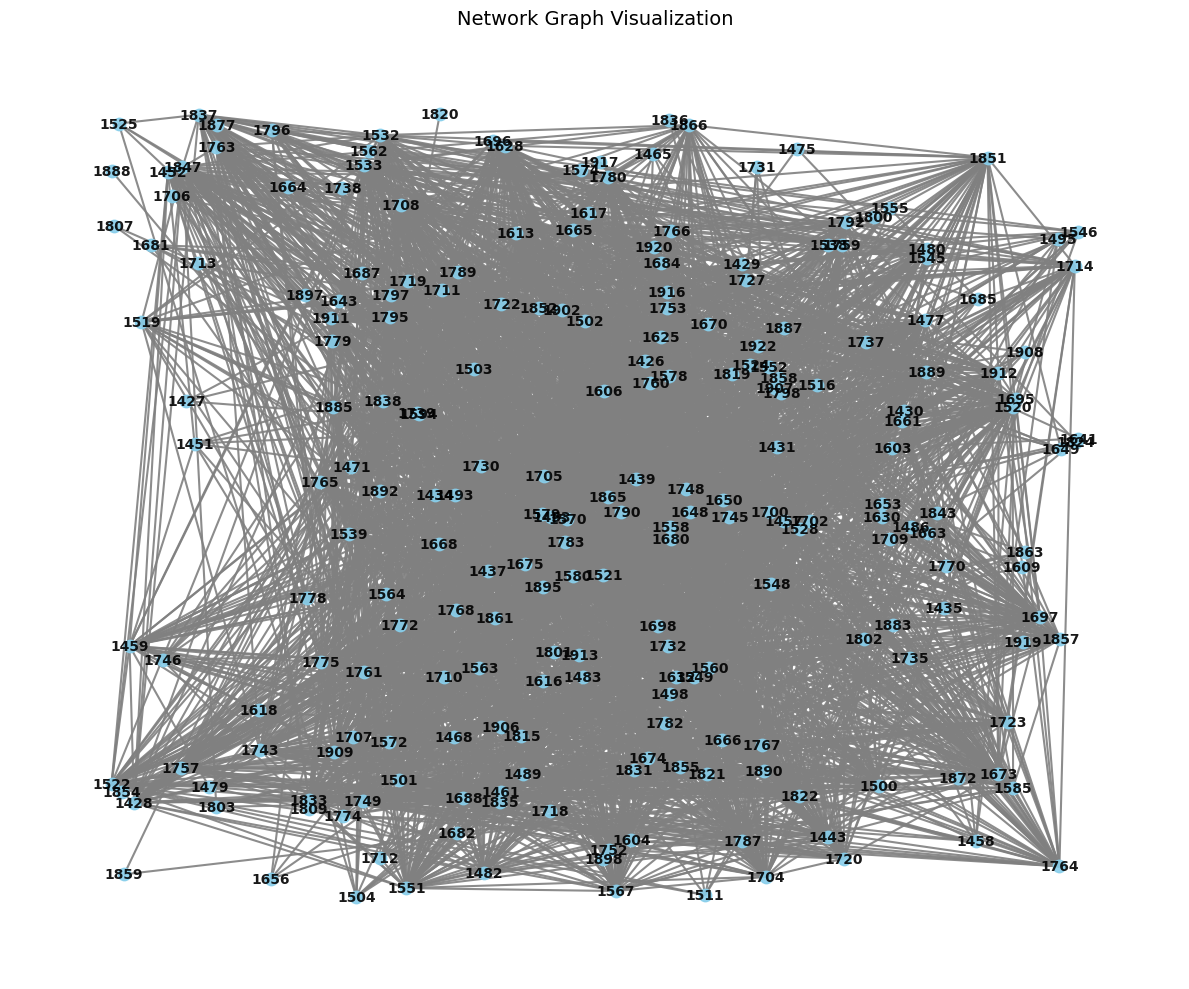

C:\Users\wen\AppData\Local\Temp\ipykernel_42256\3632115024.py:63: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for arrowsize.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


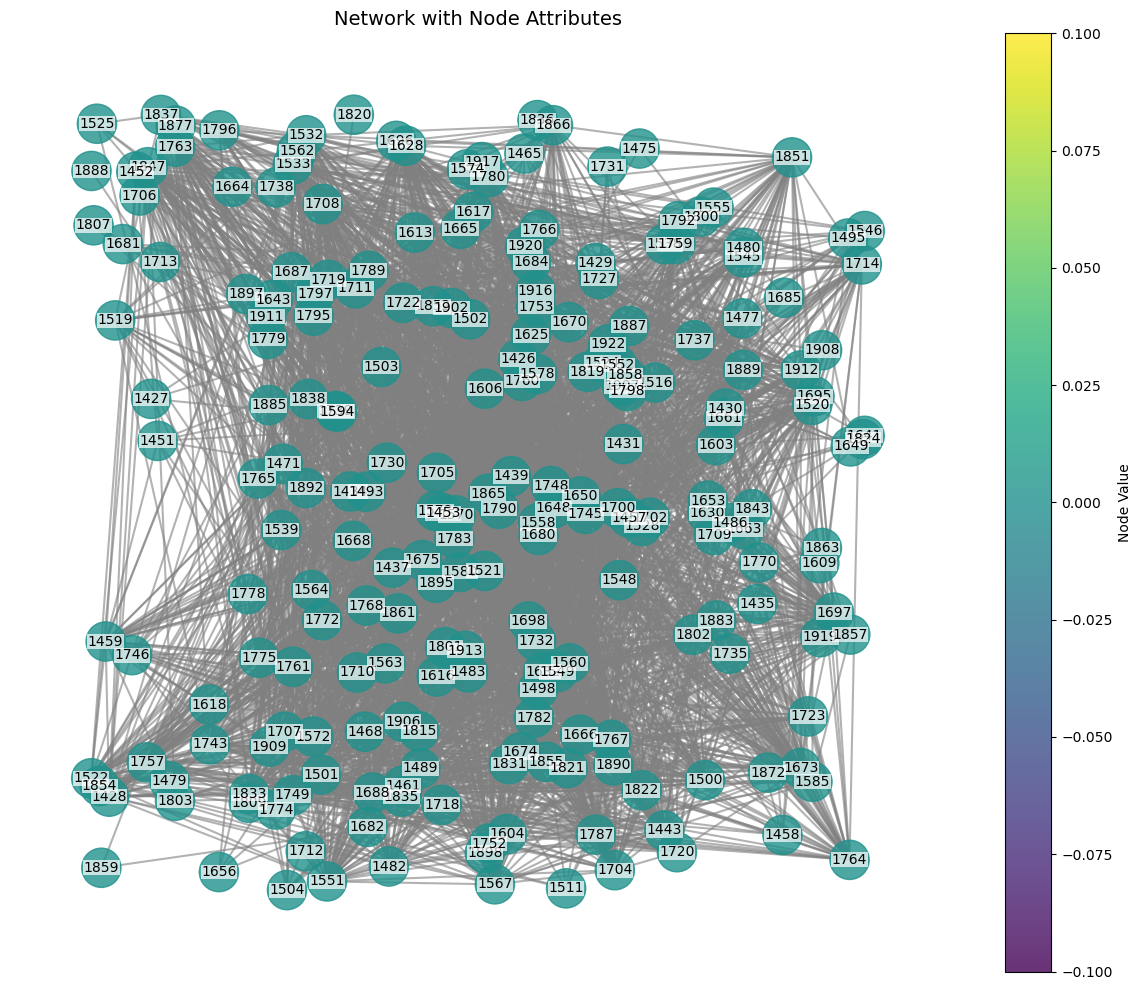

In [12]:
import matplotlib.pyplot as plt
import networkx as nx

# 读取GML文件
G = nx.read_gml("primaryschool/primaryschool_s_1.gml")

# 设置更大的画布
plt.figure(figsize=(12, 10))

# 改进的布局算法（调整参数避免节点重叠）
pos = nx.spring_layout(
    G, 
    k=0.15,  # 节点间最优距离（增大此值可使节点更分散）
    iterations=50,  # 迭代次数
    seed=42  # 固定随机种子保证可重复性
)
# 使用更高效的算法
pos = nx.random_layout(G)  # 随机布局

# 优化绘图参数
nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=80,  # 增大节点尺寸
    node_color="skyblue",  # 默认节点颜色
    edge_color="gray",  # 边颜色
    width=1.5,  # 边宽度
    alpha=0.9,  # 透明度
    font_size=10,  # 标签字体大小
    font_weight="bold",
    arrowsize=15  # 箭头大小（如有向图）
)

# 添加标题和调整边距
plt.title("Network Graph Visualization", fontsize=14)
plt.tight_layout()
plt.axis('off')  # 关闭坐标轴
plt.show()

# 带属性的高级绘制（使用颜色映射）
plt.figure(figsize=(12, 10))

# 提取节点属性值（处理可能的缺失值）
node_values = [G.nodes[n].get('value', 0) for n in G.nodes]
node_colors = node_values if all([isinstance(x, (int, float)) for x in node_values]) else "lightblue"

# 创建带颜色映射的绘图
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_size=800,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    alpha=0.8
)

# 添加颜色条（如果是数值型数据）
if isinstance(node_colors, list):
    plt.colorbar(nodes, label="Node Value")

# 绘制边（单独控制样式）
nx.draw_networkx_edges(
    G,
    pos,
    width=1.5,
    edge_color="gray",
    alpha=0.6,
    arrowstyle='->' if G.is_directed() else None,
    arrowsize=15
)

# 绘制标签（优化显示）
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_family="sans-serif",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor='none', pad=0.3)
)

plt.title("Network with Node Attributes", fontsize=14)
plt.tight_layout()
plt.axis('off')
plt.show()